# 05 — Recocido Simulado (Simulated Annealing)
**Metaheurísticas — Notebook 5 de 5**

El Recocido Simulado (Kirkpatrick, Gelatt & Vecchi, **1983**) es una metaheurística
de **trayectoria** (una sola solución) inspirada en la metalurgia: al enfriar lentamente
un metal, sus átomos se ordenan en una estructura cristalina de baja energía.
SA trata el objetivo como "energía" y **acepta movimientos que empeoran con
probabilidad que decrece al enfriar**.

## ¿Qué aprenderás?
1. La **regla de Metrópolis** y por qué aceptar peoras ayuda.
2. **Programas de enfriamiento** (geométrico, lineal, logarítmico).
3. Motor SA genérico aplicado a:
   - **Ejemplo 1 — Coloración de Grafos** (20 nodos).
   - **Ejemplo 2 — Función de Schwefel** (muy multimodal, 2D).
4. Estimación automática de $T_0$.
5. La garantía teórica de convergencia y sus límites prácticos.


## 1. La regla de Metrópolis

Proponer un vecino $s'$ al azar; calcular $\Delta = \text{costo}(s') - \text{costo}(s)$:

- Si $\Delta \leq 0$ (mejora o igual): **siempre aceptar**.
- Si $\Delta > 0$ (empeora): aceptar con probabilidad $P = \exp(-\Delta / T)$.

La **temperatura** $T$ gobierna la tolerancia:

| Temperatura | Comportamiento |
|---|---|
| $T$ muy alta | $\exp(-\Delta/T) \approx 1$ — casi todo se acepta — exploración libre |
| $T$ moderada | Se aceptan peoras pequeñas — balance exploración/explotación |
| $T \to 0$ | $\exp(-\Delta/T) \approx 0$ — solo mejoras — búsqueda local greedy |

## 2. Programas de enfriamiento

| Programa | Fórmula | Característica |
|---|---|---|
| Geométrico | $T \leftarrow \alpha T$, $\alpha \in (0.8, 0.999)$ | El más común; simple y efectivo |
| Lineal | $T \leftarrow T - c$ | Cae a ritmo constante; puede llegar a 0 prematuramente |
| Logarítmico | $T \leftarrow c / \ln(1+t)$ | Garantiza convergencia teórica; imprácticamente lento |

## 3. El algoritmo

```
funcion RecocidoSimulado(s0, T0, alpha, n_iter):
    s <- s0;  s_mejor <- s0;  T <- T0
    repetir n_iter veces:
        s' <- vecino aleatorio de s
        delta <- costo(s') - costo(s)
        si delta <= 0 o aleatorio() < exp(-delta/T):
            s <- s'         <- aceptar (incluso si empeora)
        si costo(s) < costo(s_mejor): s_mejor <- s
        T <- alpha * T      <- enfriar
    retornar s_mejor
```

**Diferencias clave:**
- vs. Búsqueda Local: SA puede moverse a soluciones peores.
- vs. Tabú: SA no usa memoria; la aceptación es estocástica.
- vs. GA: SA mantiene *una sola* solución; GA mantiene una población.


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("common.py")))
import numpy as np
import matplotlib.pyplot as plt
import common

G = common.crear_grafo(n=20, prob=0.35, seed=42)
pos = common.posiciones_grafo(G, seed=42)
n = G.number_of_nodes()

s_greedy = common.coloracion_greedy(G, seed=0)
print(f"Grafo: {n} nodos, {G.number_of_edges()} aristas")
print(f"Greedy: {common.num_colores(s_greedy)} colores, costo={common.costo(s_greedy, G)}")


Grafo: 20 nodos, 76 aristas
Greedy: 5 colores, costo=5


In [2]:
def recocido_simulado(G, s0, T0=20.0, alpha=0.995, n_iter=5000, seed=0):
    """
    Recocido Simulado para Coloracion de Grafos.

    Vecino: cambiar el color de un nodo aleatorio.
    T0: temperatura inicial (debe ser alta para aceptar ~80% de movimientos al inicio).
    alpha: tasa de enfriamiento geometrico (T <- alpha*T cada iteracion).

    Retorna: (mejor_sol, mejor_costo, hist_mejor, hist_actual, hist_temp)
    """
    rng = np.random.default_rng(seed)
    adj = {v: list(G.neighbors(v)) for v in range(n)}

    s_actual = list(s0)
    costo_actual = common.costo(s_actual, G)
    s_mejor = list(s_actual); costo_mejor = costo_actual
    T = T0
    hist_mejor, hist_actual, hist_T = [costo_mejor], [costo_actual], [T]

    for _ in range(n_iter):
        # Generar vecino
        v = int(rng.integers(0, n))
        k_max = max(s_actual) + 2
        nuevo_c = int(rng.integers(0, k_max))

        vecino = list(s_actual)
        vecino[v] = nuevo_c
        c_vecino = common.costo(vecino, G)

        delta = c_vecino - costo_actual
        if delta <= 0:
            acepta = True
        else:
            prob = np.exp(-delta / T) if T > 1e-10 else 0.0
            acepta = rng.random() < prob

        if acepta:
            s_actual = vecino; costo_actual = c_vecino

        if costo_actual < costo_mejor:
            s_mejor = list(s_actual); costo_mejor = costo_actual

        T *= alpha
        hist_mejor.append(costo_mejor)
        hist_actual.append(costo_actual)
        hist_T.append(T)

    return s_mejor, costo_mejor, hist_mejor, hist_actual, hist_T

sol_sa, costo_sa, hist_sa, hist_cur, hist_T = recocido_simulado(
    G, s_greedy, T0=20.0, alpha=0.995, n_iter=6000, seed=1)

print(f"Recocido Simulado resultado:")
print(f"  Colores: {common.num_colores(sol_sa)}")
print(f"  Conflictos: {common.calcular_conflictos(sol_sa, G)}")
print(f"  Valida: {common.coloracion_valida(sol_sa, G)}")
print(f"\nMejora: {common.num_colores(s_greedy)} -> {common.num_colores(sol_sa)} colores")


Recocido Simulado resultado:
  Colores: 5
  Conflictos: 0
  Valida: True

Mejora: 5 -> 5 colores


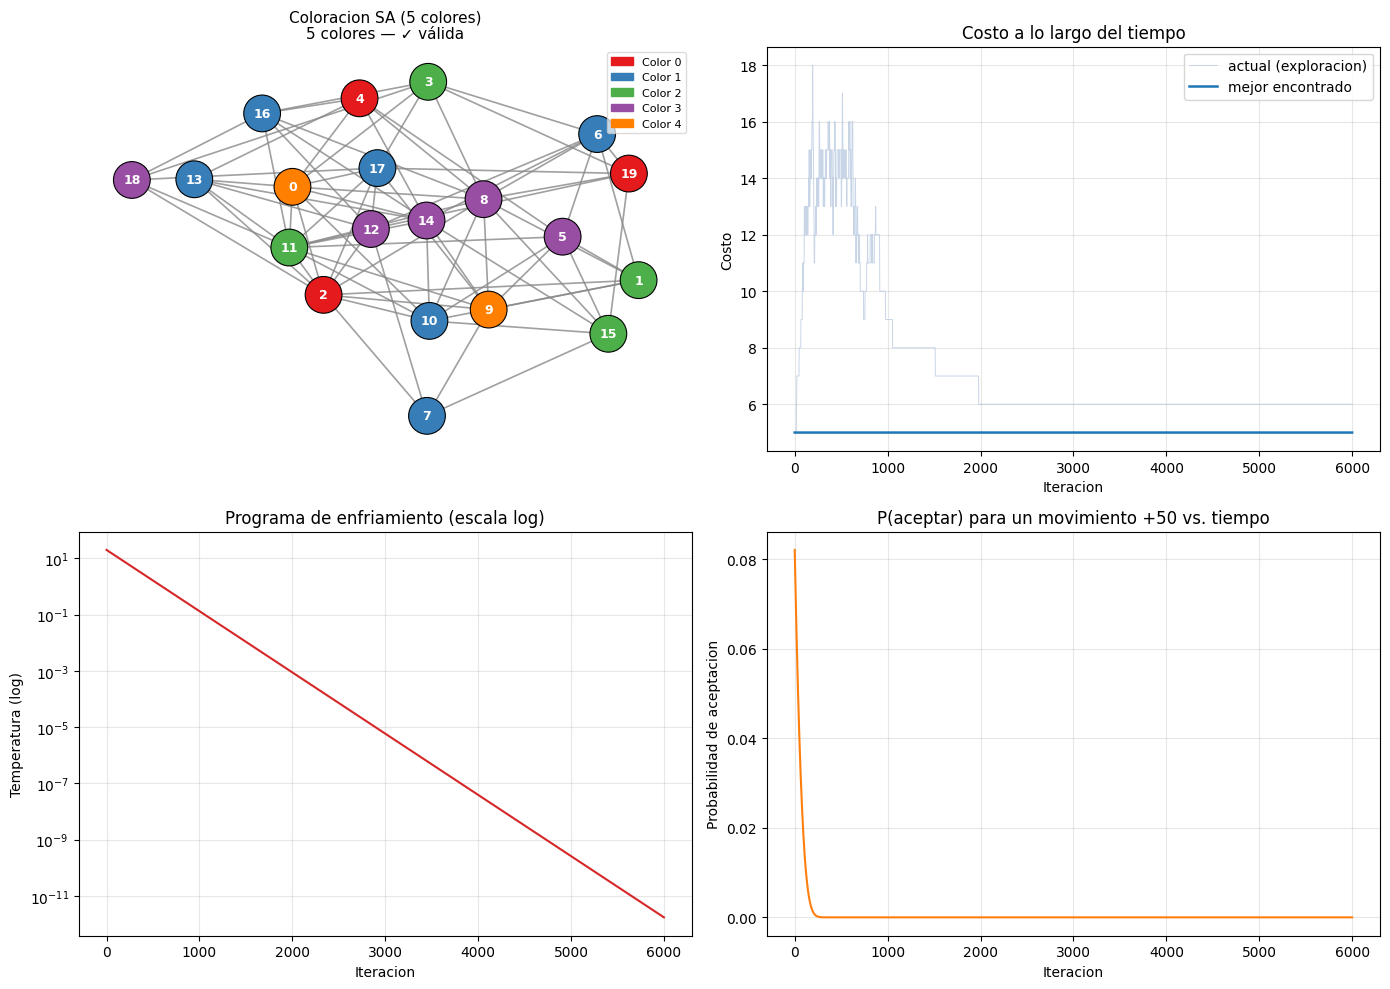

Al inicio (T alto) casi todo se acepta; al final (T bajo) solo mejoras pasan.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

common.plot_grafo(G, sol_sa,
    f"Coloracion SA ({common.num_colores(sol_sa)} colores)", ax=axes[0,0], pos=pos)

axes[0,1].plot(hist_cur, color="lightsteelblue", lw=0.7, alpha=0.7, label="actual (exploracion)")
axes[0,1].plot(hist_sa, color="tab:blue", lw=1.8, label="mejor encontrado")
axes[0,1].set_title("Costo a lo largo del tiempo")
axes[0,1].set_xlabel("Iteracion"); axes[0,1].set_ylabel("Costo")
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(hist_T, color="tab:red", lw=1.5)
axes[1,0].set_yscale("log")
axes[1,0].set_title("Programa de enfriamiento (escala log)")
axes[1,0].set_xlabel("Iteracion"); axes[1,0].set_ylabel("Temperatura (log)")
axes[1,0].grid(True, alpha=0.3)

T_arr = np.array(hist_T); delta_ref = 50.0
prob_arr = np.exp(-delta_ref / np.maximum(T_arr, 1e-10))
axes[1,1].plot(prob_arr, color="tab:orange", lw=1.5)
axes[1,1].set_title(f"P(aceptar) para un movimiento +{delta_ref:.0f} vs. tiempo")
axes[1,1].set_xlabel("Iteracion"); axes[1,1].set_ylabel("Probabilidad de aceptacion")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("Al inicio (T alto) casi todo se acepta; al final (T bajo) solo mejoras pasan.")


### Elección automática de $T_0$

Receta práctica: muestrear $M$ movimientos aleatorios de empeora, calcular
$\overline{|\Delta|}$, y elegir $T_0$ tal que $P_0 = \exp(-\overline{|\Delta|}/T_0) \approx 80\%$:
$$T_0 = -\frac{\overline{|\Delta|}}{\ln(P_0)}$$


In [4]:
def estimar_T0(G, s0, M=200, P0=0.80, seed=99):
    """Estima T0 para que el P0*100% de movimientos de empeora se acepten al inicio."""
    rng = np.random.default_rng(seed)
    deltas = []; s = list(s0); c0 = common.costo(s, G)
    k_max = max(s) + 2
    for _ in range(M):
        v = int(rng.integers(0, n)); c = int(rng.integers(0, k_max))
        vec = list(s); vec[v] = c
        d = common.costo(vec, G) - c0
        if d > 0: deltas.append(d)
    if not deltas: return 1.0
    return -np.mean(deltas) / np.log(P0)

T0_auto = estimar_T0(G, s_greedy)
print(f"T0 estimado (P0=80%): {T0_auto:.2f}")
sol_auto, c_auto, hist_auto, _, _ = recocido_simulado(
    G, s_greedy, T0=T0_auto, alpha=0.995, n_iter=6000, seed=2)
print(f"Con T0 automatico: {common.num_colores(sol_auto)} colores, "
      f"valida={common.coloracion_valida(sol_auto, G)}")


T0 estimado (P0=80%): 752.79
Con T0 automatico: 5 colores, valida=True


## Ejemplo 2 — Función de Schwefel (optimización continua)

$$f(\mathbf{x}) = 418.9829 \cdot d - \sum_{i=1}^{d} x_i \sin\!\left(\sqrt{|x_i|}\right)$$

- $d=2$, $x_i \in [-500, 500]$.
- $f(\mathbf{x}^*) = 0$ en $x_i^* \approx 420.9687$ (mínimo global).
- El mínimo está alejado del centro — una búsqueda local desde el origen queda atrapada.
- Muchos valles periódicos (función seno) crean numerosos óptimos locales.

SA encuentra el mínimo porque al inicio ($T$ alto) acepta saltos entre valles.
Conforme enfría, se asienta en el mejor valle encontrado.


In [5]:
LOW_S, HIGH_S = -500.0, 500.0

def schwefel(x):
    """Funcion de Schwefel. Minimo global = 0 en x* ~ 420.97."""
    d = len(x)
    return 418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

def sa_continuo(func, d=2, T0=500.0, alpha=0.998, n_iter=15000,
                sigma=20.0, low=-500.0, high=500.0, seed=0):
    """
    SA para optimizacion continua.
    Vecino: paso gaussiano N(0, sigma) con clip a [low, high].
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(low, high, d); fx = func(x)
    x_m, fx_m = x.copy(), fx
    T = T0; hist_m, hist_a = [fx_m], [fx]

    for _ in range(n_iter):
        x_new = np.clip(x + rng.normal(0, sigma, d), low, high)
        fx_new = func(x_new)
        delta = fx_new - fx
        if delta <= 0 or rng.random() < np.exp(-delta / max(T, 1e-10)):
            x, fx = x_new, fx_new
        if fx < fx_m: x_m, fx_m = x.copy(), fx
        T *= alpha; hist_m.append(fx_m); hist_a.append(fx)

    return x_m, fx_m, hist_m, hist_a

x_m, fx_m, hist_sw, hist_sw_a = sa_continuo(schwefel, seed=5)
x_opt = np.array([420.9687, 420.9687])
print(f"SA — Schwefel (d=2):")
print(f"  Mejor punto: ({x_m[0]:.4f}, {x_m[1]:.4f})")
print(f"  f(x) = {fx_m:.4f}  (optimo global ~ 0.0 en ~ 420.97)")
print(f"  Distancia al optimo: {np.linalg.norm(x_m - x_opt):.4f}")


SA — Schwefel (d=2):
  Mejor punto: (421.1949, 420.8882)
  f(x) = 0.0073  (optimo global ~ 0.0 en ~ 420.97)
  Distancia al optimo: 0.2401


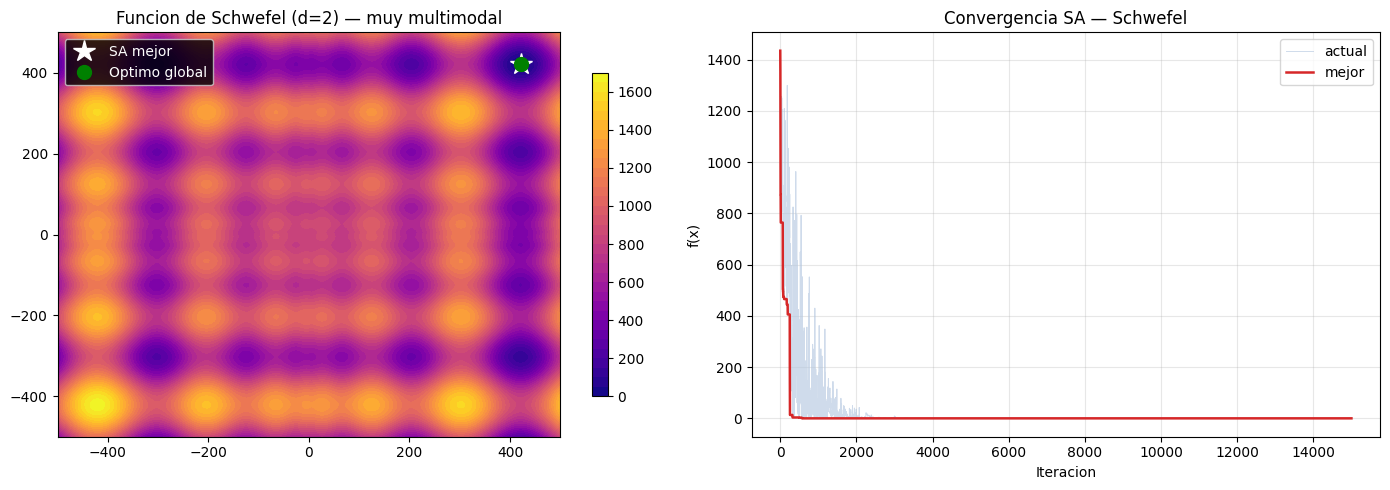

In [6]:
g = np.linspace(LOW_S, HIGH_S, 300)
X, Y = np.meshgrid(g, g)
Z = np.vectorize(lambda a,b: schwefel(np.array([a,b])))(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cf = axes[0].contourf(X, Y, Z, levels=35, cmap="plasma")
axes[0].plot(x_m[0], x_m[1], "w*", markersize=16, label="SA mejor")
axes[0].plot(420.9687, 420.9687, "go", markersize=10, label="Optimo global")
axes[0].set_title("Funcion de Schwefel (d=2) — muy multimodal")
axes[0].legend(facecolor="black", labelcolor="white")
plt.colorbar(cf, ax=axes[0], shrink=0.8)

axes[1].plot(hist_sw_a, color="lightsteelblue", lw=0.7, alpha=0.6, label="actual")
axes[1].plot(hist_sw, color="tab:red", lw=1.8, label="mejor")
axes[1].set_title("Convergencia SA — Schwefel")
axes[1].set_xlabel("Iteracion"); axes[1].set_ylabel("f(x)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Parámetros, complejidad y preguntas frecuentes

**Complejidad:** $O(n_{\text{iter}})$ evaluaciones. Footprint de memoria: $O(n)$ — mucho menor
que GA o ACO que guardan poblaciones o matrices de feromona.

**¿SA garantiza el óptimo global?**
Teóricamente sí, con enfriamiento logarítmico $T_t = c/\ln(1+t)$ suficientemente lento
(convergencia en probabilidad al óptimo global). En la práctica se usa enfriamiento
geométrico que es mucho más rápido pero sin garantía formal.

**¿Por qué aceptar peoras?**
Para escapar óptimos locales. Un descenso greedy no puede "subir la colina" para
luego bajar a un valle más profundo. SA puede, mientras $T$ sea alta.

**¿Diferencia entre SA y Búsqueda Tabú?**
- SA: aceptación **probabilística** de peoras; sin memoria de movimientos.
- Tabú: siempre acepta el mejor movimiento disponible (aunque empeore); usa memoria explícita.
SA es más simple; Tabú puede ser más eficiente con buen vecindario definido.

**¿Qué es el recalentamiento (reheating)?**
Incrementar $T$ cuando la búsqueda se estanca (no mejora en muchas iteraciones).
Permite escapar de óptimos locales profundos en etapas avanzadas.

## Ejercicios
1. Implementa **recalentamiento**: si el costo no mejora en 500 iter, multiplicar $T$ por 2.
2. Adapta el paso Gaussiano proporcional a $\sqrt{T}$ en Schwefel.
3. Compara enfriamiento geométrico, lineal y logarítmico en coloración.
4. Implementa estimación automática de $T_0$ para Schwefel y compara con $T_0$ manual.

## Referencias
- Kirkpatrick, Gelatt & Vecchi (1983), *Optimization by Simulated Annealing*, *Science*.
- Metropolis et al. (1953), *Equation of state calculations by fast computing machines*.
- Aarts & Korst, *Simulated Annealing and Boltzmann Machines* (1989).
